# Configuration

Cette cellule centralise les paramètres du notebook.

Si la résolution de l'écran, la taille du stimulus ou le chemin des fichiers changent, il suffit de modifier les valeurs ci-dessous.

In [2]:
# ==========================================================
# CONFIGURATION
# ==========================================================

STIMULUS_PATH = "data/stimuli/s7_stimuli_t1.jpg"

EYE_TRACKING_PATH = "data/eye_tracking/s7_tracking.csv"

FIGSIZE = (16, 10)

POINT_SIZE = 15

ALPHA = 0.7

COLORMAP = "viridis"

print("Configuration chargée")

Configuration chargée


## configuration du graphique

In [3]:
# ==========================================================
# VISUALISATION
# ==========================================================

POINT_SIZE_MIN = 20
POINT_SIZE_MAX = 300

COLORMAP = "viridis"

# Import des bibliothèques

In [4]:
#!pip install opencv-python 

In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import cv2
import numpy as np

# Chargement des données

Chargement du stimulus et des données eye-tracking.

In [6]:
eye_df = pd.read_csv(
    EYE_TRACKING_PATH
)

stimulus = cv2.imread(
    STIMULUS_PATH
)

stimulus = cv2.cvtColor(
    stimulus,
    cv2.COLOR_BGR2RGB
)

print(
    f"Nombre de mesures : {len(eye_df)}"
)

Nombre de mesures : 18247


# Préparation des coordonnées

Calcul du point moyen entre l'œil gauche et l'œil droit.

In [7]:
eye_df["x"] = (
    eye_df["gaze_x_left"]
    +
    eye_df["gaze_x_right"]
) / 2

eye_df["y"] = (
    eye_df["gaze_y_left"]
    +
    eye_df["gaze_y_right"]
) / 2

# Préparation des données

Le projet DyslexIA utilise un format standardisé contenant :

- time
- fix_x
- fix_y
- gaze_x_left
- gaze_y_left
- gaze_x_right
- gaze_y_right

Cette cellule prépare les colonnes utilisées pour la visualisation.

In [8]:
# # ==========================================================
# # PREPARATION DES DONNEES
# # ==========================================================

# eye_df["timestamp"] = eye_df["time"]

# eye_df["x"] = eye_df["fix_x"]

# eye_df["y"] = eye_df["fix_y"]

# eye_df = eye_df[
#     [
#         "timestamp",
#         "x",
#         "y",
#         "gaze_x_left",
#         "gaze_y_left",
#         "gaze_x_right",
#         "gaze_y_right"
#     ]
# ].copy()

# eye_df.head()

# Nettoyage des données

Suppression des points invalides.

In [9]:
eye_df = eye_df[
    ~(
        (eye_df["x"] == 0)
        &
        (eye_df["y"] == 0)
    )
]

print(
    f"Mesures restantes : {len(eye_df)}"
)

Mesures restantes : 18105


# Vérification des données

In [10]:
eye_df[
    [
        "x",
        "y"
    ]
].describe()

,x,y
count,18105.000000,18105.000000
mean,839.472972,513.609324
std,321.950103,217.080048
min,112.885000,90.660000
25%,578.135000,317.625000
50%,837.305000,535.780000
75%,1090.635000,700.180000
max,1541.885000,1001.270000


# Affichage du stimulus

Affichage de l'image seule afin de vérifier son chargement.

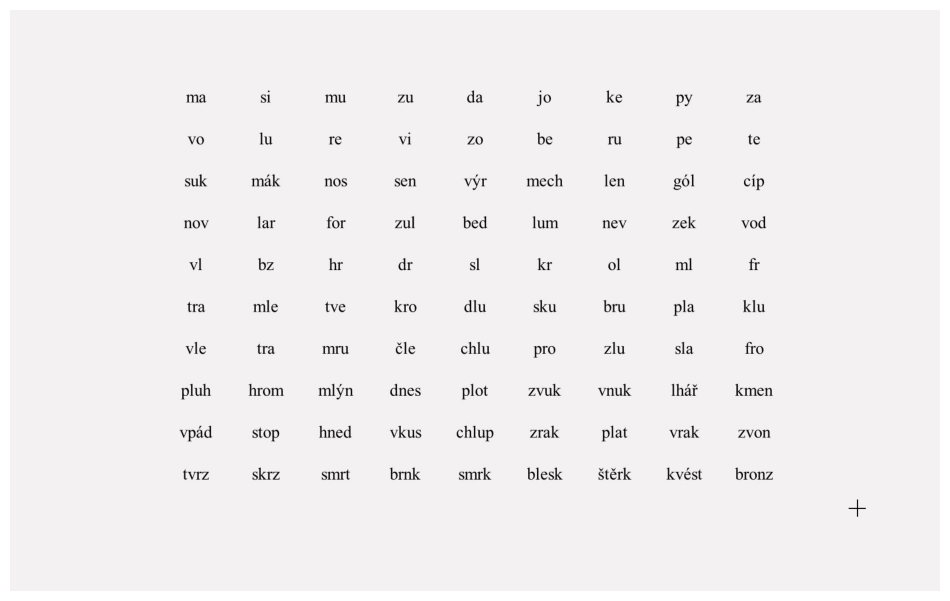

In [11]:
plt.figure(figsize=(12,8))
plt.imshow(stimulus)
plt.axis("off")
plt.show()

# Préparation de la progression temporelle

La couleur des points représentera l'avancement de la lecture.

In [12]:
eye_df["time_order"] = np.linspace(
    0,
    1,
    len(eye_df)
)

# Visualisation du parcours de lecture

Couleur :
- violet = début
- jaune = fin

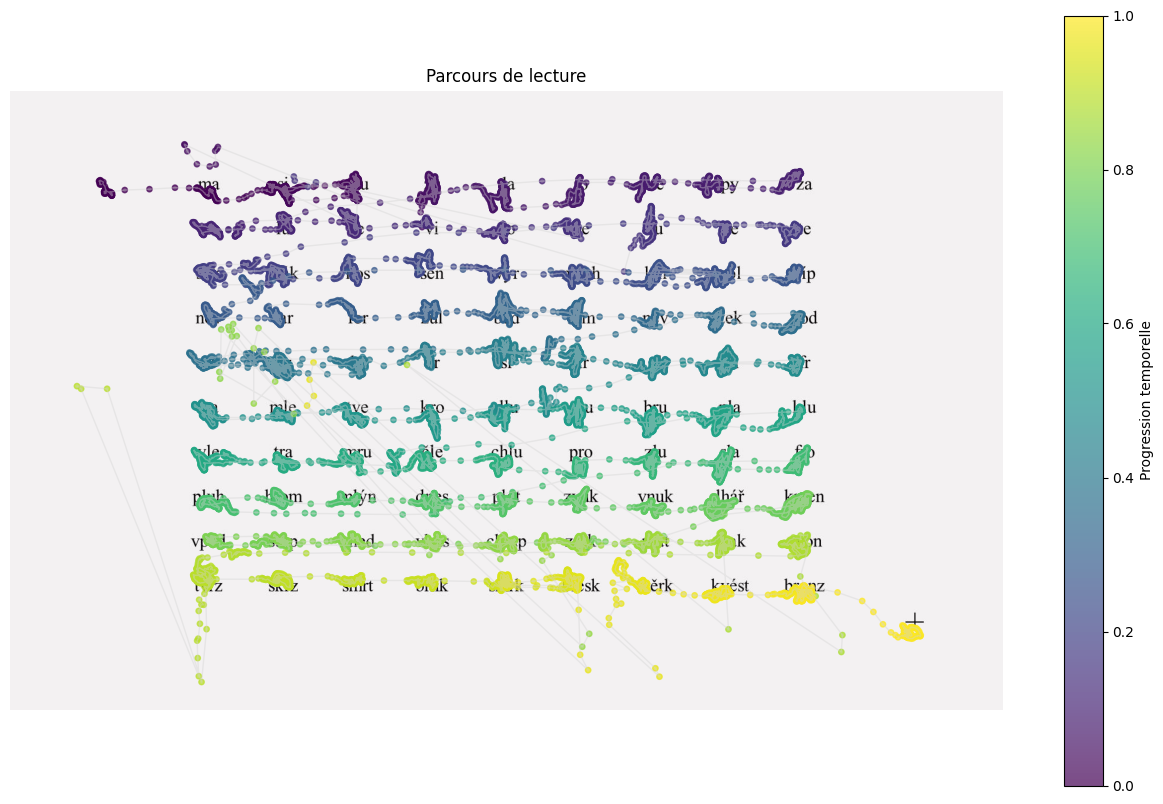

In [13]:
plt.figure(
    figsize=FIGSIZE
)

plt.imshow(
    stimulus
)

plt.plot(
    eye_df["x"],
    eye_df["y"],
    color="lightgray",
    linewidth=1,
    alpha=0.4
)

scatter = plt.scatter(
    eye_df["x"],
    eye_df["y"],
    c=eye_df["time_order"],
    cmap=COLORMAP,
    s=POINT_SIZE,
    alpha=ALPHA
)

cbar = plt.colorbar(
    scatter
)

cbar.set_label(
    "Progression temporelle"
)

plt.title(
    "Parcours de lecture"
)

plt.axis("off")

plt.show()

# Export de la visualisation

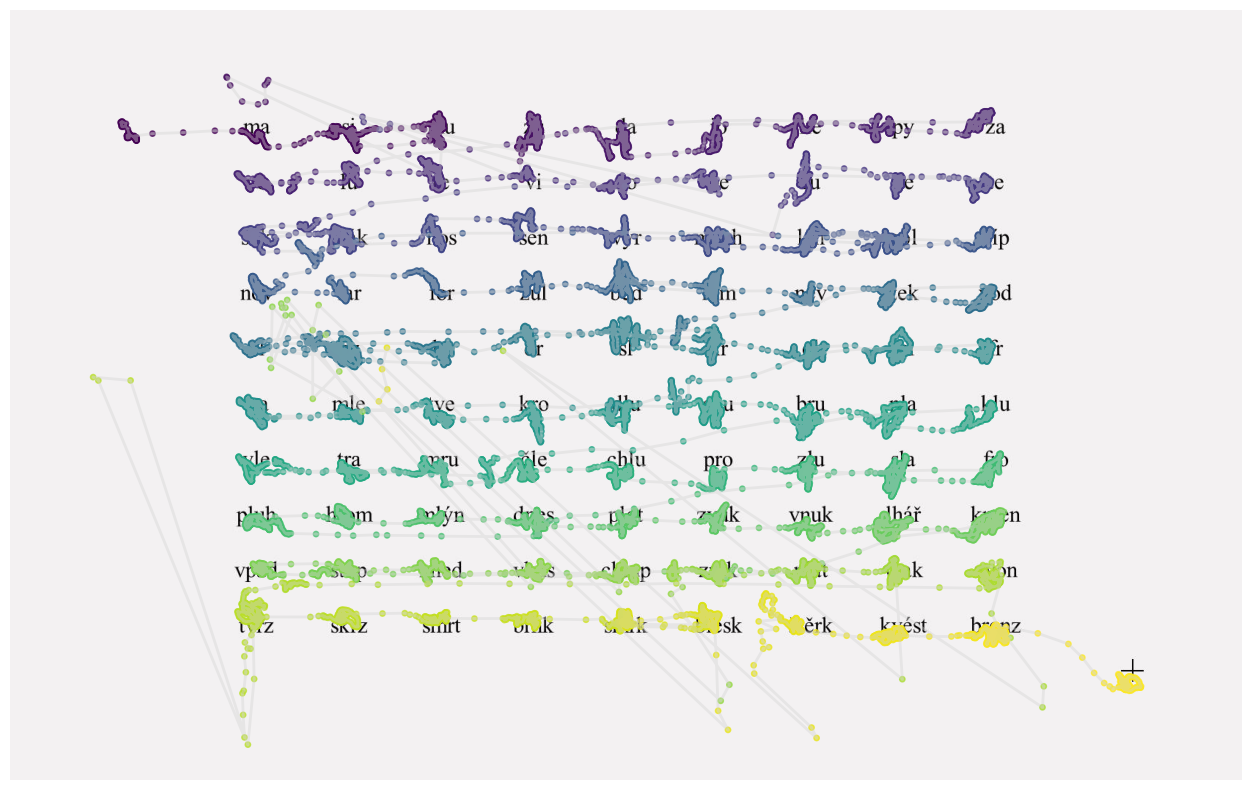

In [14]:
plt.figure(
    figsize=FIGSIZE
)

plt.imshow(
    stimulus
)

plt.plot(
    eye_df["x"],
    eye_df["y"],
    color="lightgray",
    linewidth=2,
    alpha=0.4
)

plt.scatter(
    eye_df["x"],
    eye_df["y"],
    c=eye_df["time_order"],
    cmap=COLORMAP,
    s=POINT_SIZE,
    alpha=ALPHA
)

plt.axis("off")

plt.savefig(
    "reading_path.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()